### ÜSKÜDAR ÜNİVERSİTESİ
### Yapay Zeka ve Uygulamaları
### ILHAM ASGARLI - 244312904
### Müşteri Segmentasyonu ve Davranış Analizi

Bu çalışmada bir e-ticaret işletmesinin işlem (transaction) verisi üzerinden
müşteri segmentasyonu yapıyoruz. Kullanılan yöntemler:

* **RFM analizi** (Recency, Frequency, Monetary)
* **Feature scaling** (StandardScaler) ve etkisinin karşılaştırılması
* **PCA** ile boyut indirgeme + 2B görselleştirme
* **K-Means**, **Hierarchical (Agglomerative) Clustering**, **DBSCAN**
* **Optimal cluster sayısı** seçimi: Elbow + Silhouette + Davies-Bouldin + Calinski-Harabasz
* **Segment geçerlilik analizi** ve segmentlerin yorumlanması

Veri seti: `dataset/online_retail.xlsx` — orijinal UCI *Online Retail* (https://archive.ics.uci.edu/dataset/352/online+retail) veri seti (InvoiceNo, StockCode, Description, Quantity, InvoiceDate,
UnitPrice, CustomerID, Country). İlk çalıştırmada Excel okunup
`dataset/online_retail.parquet` (yoksa `.pkl`) olarak önbelleğe alınır;
sonraki çalıştırmalar saniyeler içinde tamamlanır.


## 1. Kütüphaneler ve Ayarlar

In [195]:
%pip install numpy pandas matplotlib seaborn scikit-learn scipy openpyxl pyarrow

Note: you may need to restart the kernel to use updated packages.


In [196]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import timedelta

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import (silhouette_score, davies_bouldin_score,
                             calinski_harabasz_score, silhouette_samples)
from sklearn.neighbors import NearestNeighbors
from scipy.cluster.hierarchy import linkage, dendrogram

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110
RND = 42
np.random.seed(RND)
print("Kurulum tamam.")

Kurulum tamam.


## 2. Veriyi Yükleme

In [197]:
# Orijinal UCI Online Retail .xlsx dosyası ~23 MB; openpyxl ile her
# çalıştırmada okumak yavaştır. İlk çalıştırmada xlsx'i okuyup
# parquet'e (kurulu değilse pickle'a) önbelleğe alıyoruz; sonraki
# çalıştırmalar saniyeler içinde tamamlanır.
DATA_XLSX  = "dataset/online_retail.xlsx"
CACHE_PATH = "dataset/online_retail.parquet"

if os.path.exists(CACHE_PATH):
    df = pd.read_parquet(CACHE_PATH)
    print(f"Önbellekten yüklendi: {CACHE_PATH}")
elif os.path.exists(CACHE_PATH.replace('.parquet', '.pkl')):
    CACHE_PATH = CACHE_PATH.replace('.parquet', '.pkl')
    df = pd.read_pickle(CACHE_PATH)
    print(f"Önbellekten yüklendi: {CACHE_PATH}")
else:
    print("Excel dosyası okunuyor (ilk seferde 30-90 sn sürebilir)...")
    df = pd.read_excel(DATA_XLSX, sheet_name="Online Retail",
                       engine="openpyxl")
    df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])
    try:
        df.to_parquet(CACHE_PATH)
        print(f"Önbelleğe yazıldı: {CACHE_PATH}")
    except Exception as e:
        # pyarrow/fastparquet kurulu değilse pickle'a düş
        CACHE_PATH = CACHE_PATH.replace(".parquet", ".pkl")
        df.to_pickle(CACHE_PATH)
        print(f"parquet yazılamadı; pickle olarak kaydedildi: {CACHE_PATH}")

print("Şekil:", df.shape)
df.head()

Önbellekten yüklendi: dataset/online_retail.pkl
Şekil: (541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [198]:
print("Sütun tipleri:\n", df.dtypes)
print("\nEksik değerler:\n", df.isna().sum())
print("\nÖzet istatistikler:\n", df.describe(include='all').T.head(10))

Sütun tipleri:
 InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[us]
UnitPrice             float64
CustomerID            float64
Country                   str
dtype: object

Eksik değerler:
 InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

Özet istatistikler:
                 count   unique                                 top    freq  \
InvoiceNo    541909.0  25900.0                            573585.0  1114.0   
StockCode      541909     4070                              85123A    2313   
Description    540455     4223  WHITE HANGING HEART T-LIGHT HOLDER    2369   
Quantity     541909.0      NaN                                 NaN     NaN   
InvoiceDate    541909      NaN                                 NaN     NaN   
UnitPrice    541909.0      NaN   

## 3. Keşifsel Veri Analizi (EDA)

In [199]:
print("Tarih aralığı :", df['InvoiceDate'].min(), "->", df['InvoiceDate'].max())
print("Müşteri sayısı:", df['CustomerID'].nunique())
print("Fatura sayısı :", df['InvoiceNo'].nunique())
print("Ürün sayısı   :", df['StockCode'].nunique())
print("Ülke sayısı   :", df['Country'].nunique())

Tarih aralığı : 2010-12-01 08:26:00 -> 2011-12-09 12:50:00
Müşteri sayısı: 4372
Fatura sayısı : 25900
Ürün sayısı   : 4070
Ülke sayısı   : 38


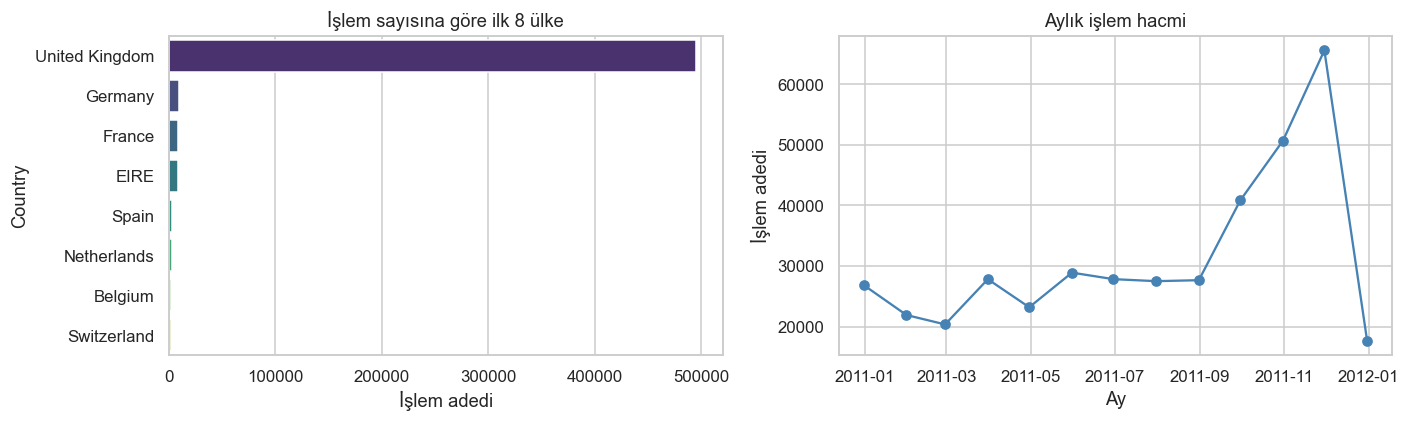

In [200]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

top_countries = df['Country'].value_counts().head(8)
sns.barplot(x=top_countries.values, y=top_countries.index, ax=axes[0],
            palette='viridis')
axes[0].set_title("İşlem sayısına göre ilk 8 ülke")
axes[0].set_xlabel("İşlem adedi")

monthly = (df.dropna(subset=['CustomerID'])
             .set_index('InvoiceDate')
             .resample('ME').size())
axes[1].plot(monthly.index, monthly.values, marker='o', color='steelblue')
axes[1].set_title("Aylık işlem hacmi")
axes[1].set_xlabel("Ay"); axes[1].set_ylabel("İşlem adedi")
plt.tight_layout(); plt.show()

## 4. Veri Temizleme

RFM analizi için iade işlemleri (negatif `Quantity`, `InvoiceNo` 'C' ile
başlar) ve eksik `CustomerID`'li satırlar çıkarılır. Ayrıca `TotalPrice`
hesaplanır.

In [201]:
before = len(df)
df = df.dropna(subset=['CustomerID']).copy()
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]
df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)]
df['CustomerID'] = df['CustomerID'].astype(int)
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']
print(f"Temizleme öncesi/sonrası: {before:,} -> {len(df):,} satır")
df.head()

Temizleme öncesi/sonrası: 541,909 -> 397,884 satır


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34


## 5. RFM Metrikleri

* **Recency (R)**  — Son işlemden bu yana geçen gün sayısı (küçük = iyi)
* **Frequency (F)** — Müşterinin yaptığı toplam fatura sayısı
* **Monetary (M)**  — Müşterinin toplam harcaması

Snapshot tarihi olarak veri setindeki son işlem tarihinin **1 gün** sonrasını
alıyoruz.

In [202]:
snapshot = df['InvoiceDate'].max() + timedelta(days=1)
print("Snapshot tarihi:", snapshot)

rfm = (df.groupby('CustomerID')
         .agg(Recency=('InvoiceDate', lambda s: (snapshot - s.max()).days),
              Frequency=('InvoiceNo', 'nunique'),
              Monetary=('TotalPrice', 'sum'))
         .reset_index())
print("RFM şekli:", rfm.shape)
rfm.describe().T

Snapshot tarihi: 2011-12-10 12:50:00
RFM şekli: (4338, 4)


,count,mean,std,min,25%,50%,75%,max
CustomerID,4338.0,15300.408022,1721.808492,12346.00,13813.250,15299.500,16778.75,18287.00
Recency,4338.0,92.536422,100.014169,1.00,18.000,51.000,142.00,374.00
Frequency,4338.0,4.272015,7.697998,1.00,1.000,2.000,5.00,209.00
Monetary,4338.0,2054.266460,8989.230441,3.75,307.415,674.485,1661.74,280206.02


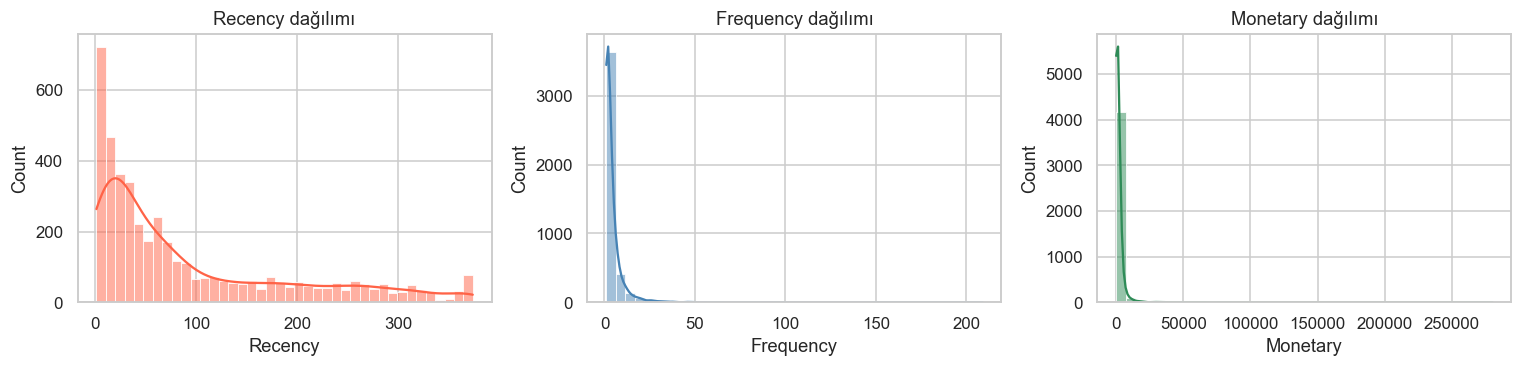

In [203]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3.5))
for ax, col, color in zip(axes, ['Recency','Frequency','Monetary'],
                          ['tomato','steelblue','seagreen']):
    sns.histplot(rfm[col], bins=40, ax=ax, color=color, kde=True)
    ax.set_title(f"{col} dağılımı")
plt.tight_layout(); plt.show()

### 5.1 Rule-based RFM Skoru (Quintile)

Skorlar 1..5 aralığında. R için tersine sıralıyoruz: en küçük Recency en
yüksek skoru alır.

In [204]:
rfm['R_score'] = pd.qcut(rfm['Recency'],   5, labels=[5,4,3,2,1]).astype(int)
rfm['F_score'] = pd.qcut(rfm['Frequency'].rank(method='first'),
                          5, labels=[1,2,3,4,5]).astype(int)
rfm['M_score'] = pd.qcut(rfm['Monetary'],   5, labels=[1,2,3,4,5]).astype(int)
rfm['RFM_Score']  = rfm['R_score'] + rfm['F_score'] + rfm['M_score']
rfm['RFM_String'] = (rfm['R_score'].astype(str) +
                     rfm['F_score'].astype(str) +
                     rfm['M_score'].astype(str))

def rule_segment(r, f, m):
    if r >= 4 and f >= 4 and m >= 4:                     return 'Champions'
    if r >= 3 and f >= 4:                                 return 'Loyal'
    if r >= 4 and f <= 2:                                 return 'New / Promising'
    if r <= 2 and f >= 4:                                 return 'At Risk'
    if r <= 2 and f <= 2 and m <= 2:                      return 'Hibernating'
    if r == 3:                                            return 'Need Attention'
    return 'Others'

rfm['RuleSegment'] = rfm.apply(
    lambda x: rule_segment(x.R_score, x.F_score, x.M_score), axis=1)
rfm['RuleSegment'].value_counts()

RuleSegment
Champions          962
Others             923
Hibernating        824
Need Attention     537
Loyal              498
New / Promising    319
At Risk            275
Name: count, dtype: int64

## 6. Genişletilmiş Özellik Kümesi & *Curse of Dimensionality*

Daha zengin bir segmentasyon için RFM'in yanına davranışsal özellikler
ekliyoruz:

* `AvgBasketValue`  – fatura başına ortalama harcama
* `AvgQtyPerInvoice` – fatura başına ortalama adet
* `UniqueProducts`  – satın alınan farklı ürün sayısı
* `Tenure`           – ilk satın alma tarihinden bu yana geçen gün
* `PurchaseInterval`– ortalama iki sipariş arası gün

Boyut sayısı arttıkça uzaklık ölçütleri *anlamını kaybeder* (curse of
dimensionality). Bunu hem **PCA** ile boyut indirgeyerek hem de farklı
mesafe ölçütleri/ölçeklendirme stratejileri kullanarak yöneteceğiz.

In [205]:
extra = (df.groupby('CustomerID')
           .agg(AvgBasketValue=('TotalPrice', lambda s: s.sum() /
                                 max(1, df.loc[s.index,'InvoiceNo'].nunique())),
                AvgQtyPerInvoice=('Quantity', 'mean'),
                UniqueProducts=('StockCode', 'nunique'),
                FirstPurchase=('InvoiceDate', 'min'))
           .reset_index())
extra['Tenure'] = (snapshot - extra['FirstPurchase']).dt.days
extra = extra.drop(columns='FirstPurchase')

rfm = rfm.merge(extra, on='CustomerID', how='left')
rfm['PurchaseInterval'] = np.where(rfm['Frequency'] > 1,
                                   rfm['Tenure'] / rfm['Frequency'],
                                   rfm['Tenure'])
rfm.head()

,CustomerID,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_Score,RFM_String,RuleSegment,AvgBasketValue,AvgQtyPerInvoice,UniqueProducts,Tenure,PurchaseInterval
0,12346,326,1,77183.60,1,1,5,7,115,Others,77183.600000,74215.000000,1,326,326.000000
1,12347,2,7,4310.00,5,5,5,15,555,Champions,615.714286,13.505495,103,367,52.428571
2,12348,75,4,1797.24,2,4,4,10,244,At Risk,449.310000,75.516129,22,358,89.500000
3,12349,19,1,1757.55,4,1,4,9,414,New / Promising,1757.550000,8.643836,73,19,19.000000
4,12350,310,1,334.40,1,1,2,4,112,Hibernating,334.400000,11.588235,17,310,310.000000


## 7. Çarpıklığın Düzeltilmesi ve Feature Scaling

RFM ve davranışsal özellikler genellikle güçlü sağa çarpıktır. Bu durumda
mesafe-tabanlı algoritmalar (K-Means, DBSCAN, Hiyerarşik) bozulur. İki
adım uyguluyoruz:

1. **log1p** dönüşümü  →  çarpıklığı azaltır
2. **StandardScaler**  →  her özelliği eşit ağırlığa getirir

Aşağıda *ölçeklenmemiş* ve *ölçeklenmiş* veride K-Means'in nasıl farklı
sonuç verdiğini de gösteriyoruz.

In [206]:
features = ['Recency','Frequency','Monetary','AvgBasketValue',
            'AvgQtyPerInvoice','UniqueProducts','Tenure','PurchaseInterval']

X_raw = rfm[features].copy()
X_log = X_raw.copy()
for col in features:
    X_log[col] = np.log1p(X_log[col])

scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X_log),
                         columns=features, index=X_log.index)

print("Çarpıklık (skew) — ham veri:")
print(X_raw.skew().round(2).to_string())
print("\nÇarpıklık (skew) — log+scale sonrası:")
print(X_scaled.skew().round(2).to_string())

Çarpıklık (skew) — ham veri:
Recency              1.25
Frequency           12.07
Monetary            19.32
AvgBasketValue      41.69
AvgQtyPerInvoice    56.61
UniqueProducts       6.92
Tenure              -0.37
PurchaseInterval     1.46

Çarpıklık (skew) — log+scale sonrası:
Recency            -0.38
Frequency           1.21
Monetary            0.39
AvgBasketValue      0.23
AvgQtyPerInvoice    1.73
UniqueProducts     -0.24
Tenure             -1.56
PurchaseInterval   -0.30


In [207]:
# --- Scaling etkisini göstermek: aynı K=4 K-Means ham vs scaled
km_raw    = KMeans(n_clusters=4, random_state=RND, n_init=10).fit(X_raw)
km_scaled = KMeans(n_clusters=4, random_state=RND, n_init=10).fit(X_scaled)

print("Silhouette  | ham veri  : %.3f" %
      silhouette_score(X_raw,    km_raw.labels_))
print("Silhouette  | log+scaled: %.3f" %
      silhouette_score(X_scaled, km_scaled.labels_))
print("Davies-Bouldin | ham    : %.3f  |  log+scaled: %.3f" % (
      davies_bouldin_score(X_raw,    km_raw.labels_),
      davies_bouldin_score(X_scaled, km_scaled.labels_)))

Silhouette  | ham veri  : 0.951
Silhouette  | log+scaled: 0.223
Davies-Bouldin | ham    : 0.576  |  log+scaled: 1.387


## 8. PCA — Boyut İndirgeme

Hem küme görselleştirmesi için hem de boyut sayısını düşürerek
*curse of dimensionality*'nin etkisini azaltmak için PCA uyguluyoruz.

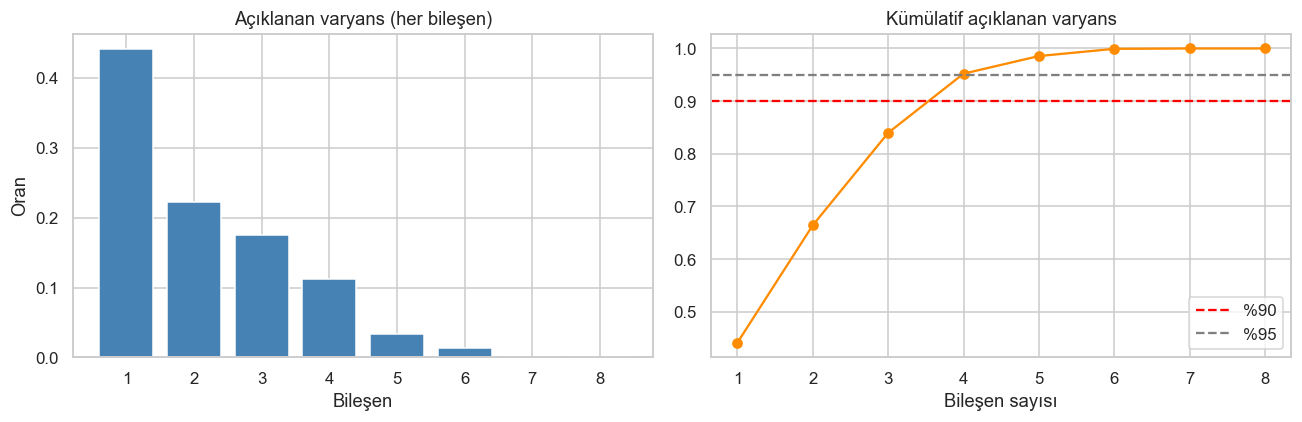

Kümülatif: [0.441 0.664 0.84  0.952 0.986 0.999 1.    1.   ]


In [208]:
pca_full = PCA(random_state=RND).fit(X_scaled)
explained = np.cumsum(pca_full.explained_variance_ratio_)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].bar(range(1, len(features)+1), pca_full.explained_variance_ratio_,
          color='steelblue')
ax[0].set_title("Açıklanan varyans (her bileşen)")
ax[0].set_xlabel("Bileşen"); ax[0].set_ylabel("Oran")

ax[1].plot(range(1, len(features)+1), explained, marker='o', color='darkorange')
ax[1].axhline(0.90, color='red', ls='--', label='%90')
ax[1].axhline(0.95, color='gray', ls='--', label='%95')
ax[1].set_title("Kümülatif açıklanan varyans")
ax[1].set_xlabel("Bileşen sayısı"); ax[1].legend()
plt.tight_layout(); plt.show()
print("Kümülatif:", np.round(explained, 3))

In [209]:
# Varyansın %90+'ını koruyan bileşen sayısı
n_components = int(np.searchsorted(explained, 0.90) + 1)
print(f"Seçilen bileşen sayısı (>=%90 varyans): {n_components}")
pca = PCA(n_components=n_components, random_state=RND).fit(X_scaled)
X_pca = pd.DataFrame(pca.transform(X_scaled),
                     columns=[f'PC{i+1}' for i in range(n_components)],
                     index=X_scaled.index)

# Görselleştirme için 2B projeksiyon
pca2 = PCA(n_components=2, random_state=RND).fit(X_scaled)
X_pca2 = pd.DataFrame(pca2.transform(X_scaled), columns=['PC1','PC2'])
print("X_pca şekli:", X_pca.shape, "  X_pca2 şekli:", X_pca2.shape)

Seçilen bileşen sayısı (>=%90 varyans): 4
X_pca şekli: (4338, 4)   X_pca2 şekli: (4338, 2)


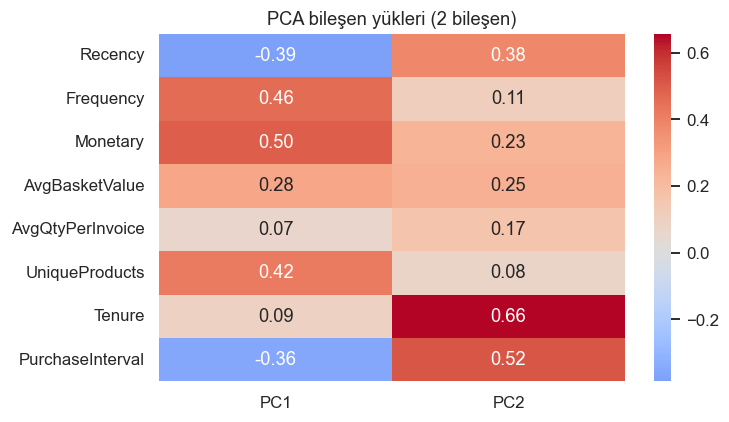

In [210]:
# PCA bileşen yükleri
loadings = pd.DataFrame(pca2.components_.T,
                        columns=['PC1','PC2'], index=features)
plt.figure(figsize=(7,4))
sns.heatmap(loadings, cmap='coolwarm', center=0, annot=True, fmt='.2f')
plt.title("PCA bileşen yükleri (2 bileşen)")
plt.tight_layout(); plt.show()

## 9. K-Means — Optimal `k` Seçimi

Dört farklı kriteri birlikte değerlendireceğiz:

| Metrik | İdeal yön |
|---|---|
| Inertia / SSE (Elbow) | Dirsek noktası |
| Silhouette | Yüksek |
| Davies-Bouldin | Düşük |
| Calinski-Harabasz | Yüksek |


In [211]:
K_RANGE = range(2, 11)
inertias, sils, dbs, chs = [], [], [], []
for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=RND, n_init=10).fit(X_pca)
    inertias.append(km.inertia_)
    sils.append(silhouette_score(X_pca, km.labels_))
    dbs.append(davies_bouldin_score(X_pca, km.labels_))
    chs.append(calinski_harabasz_score(X_pca, km.labels_))

metrics_df = pd.DataFrame({'k': list(K_RANGE),
                           'Inertia': inertias,
                           'Silhouette': sils,
                           'DaviesBouldin': dbs,
                           'CalinskiHarabasz': chs})
metrics_df

,k,Inertia,Silhouette,DaviesBouldin,CalinskiHarabasz
0,2,23055.881371,0.284447,1.328819,1878.347048
1,3,18219.514534,0.298907,1.224707,1763.569880
2,4,15837.453792,0.241742,1.295001,1569.530257
3,5,14087.989918,0.250773,1.180268,1457.533288
4,6,12881.837007,0.219989,1.255714,1356.032619
5,7,12048.643666,0.210077,1.286081,1257.827863
6,8,11262.368170,0.206069,1.347707,1196.315765
7,9,10580.803258,0.202458,1.320341,1148.801361
8,10,10020.982283,0.207091,1.262790,1104.825757


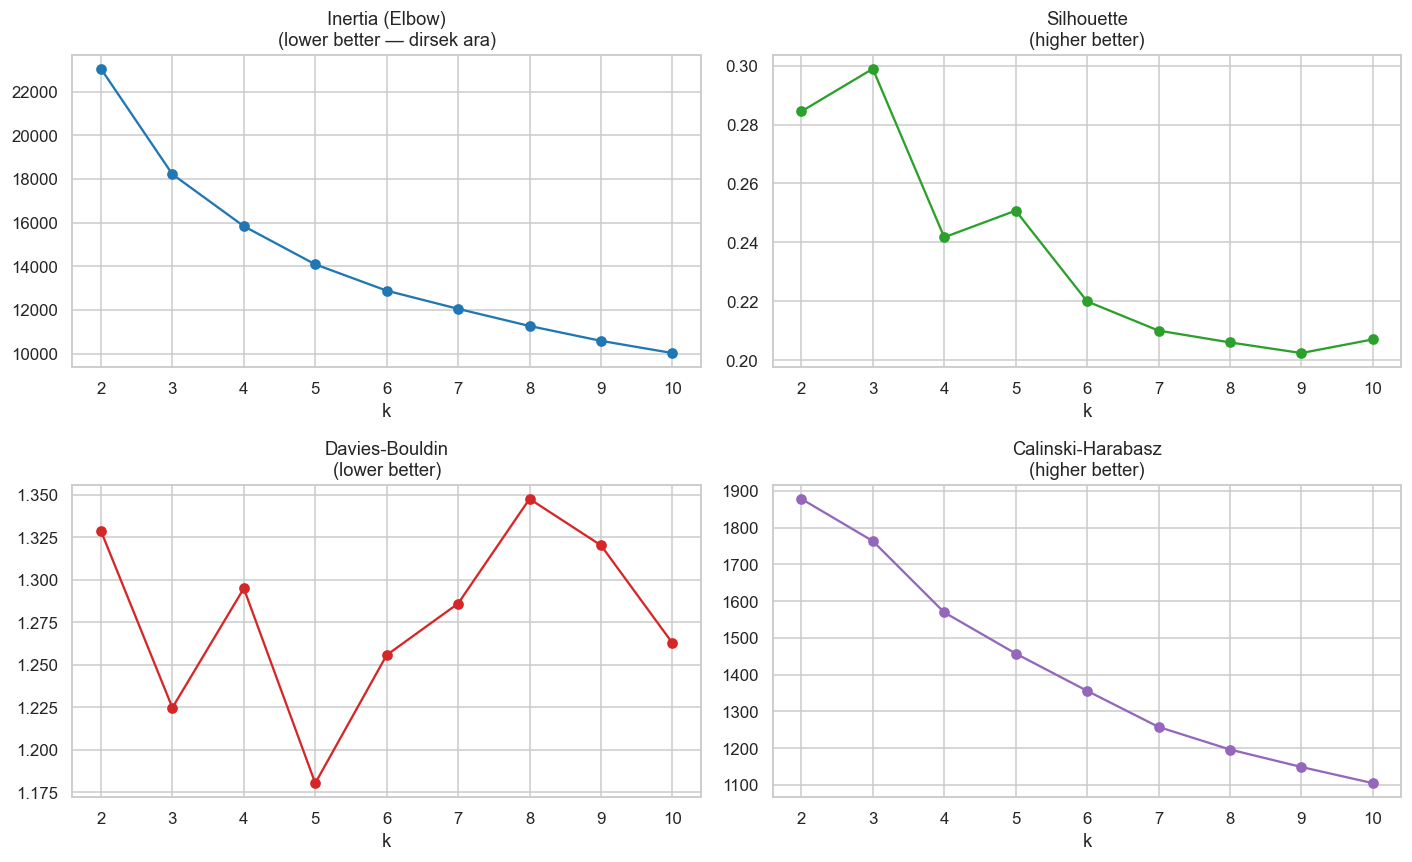

In [212]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
axes = axes.flatten()
configs = [
    ('Inertia (Elbow)',     inertias, 'tab:blue',    'lower better — dirsek ara'),
    ('Silhouette',          sils,     'tab:green',   'higher better'),
    ('Davies-Bouldin',      dbs,      'tab:red',     'lower better'),
    ('Calinski-Harabasz',   chs,      'tab:purple',  'higher better'),
]
for ax, (title, vals, col, sub) in zip(axes, configs):
    ax.plot(list(K_RANGE), vals, marker='o', color=col)
    ax.set_title(f"{title}\n({sub})")
    ax.set_xlabel("k"); ax.set_xticks(list(K_RANGE))
plt.tight_layout(); plt.show()

In [213]:
# Optimal k seçimi: silhouette maks + DBI min'e göre konsensüs
best_k_sil = int(metrics_df.loc[metrics_df['Silhouette'].idxmax(), 'k'])
best_k_dbi = int(metrics_df.loc[metrics_df['DaviesBouldin'].idxmin(), 'k'])
best_k_ch  = int(metrics_df.loc[metrics_df['CalinskiHarabasz'].idxmax(), 'k'])
print(f"Silhouette en iyi k = {best_k_sil}")
print(f"Davies-Bouldin en iyi k = {best_k_dbi}")
print(f"Calinski-Harabasz en iyi k = {best_k_ch}")

# Mod alarak konsensüs
from collections import Counter
votes = Counter([best_k_sil, best_k_dbi, best_k_ch])
OPT_K = votes.most_common(1)[0][0]
print(f"\nSeçilen optimal k = {OPT_K}")

Silhouette en iyi k = 3
Davies-Bouldin en iyi k = 5
Calinski-Harabasz en iyi k = 2

Seçilen optimal k = 3


In [214]:
kmeans = KMeans(n_clusters=OPT_K, random_state=RND, n_init=20).fit(X_pca)
rfm['KMeans_Cluster'] = kmeans.labels_

print("Küme büyüklükleri:")
print(rfm['KMeans_Cluster'].value_counts().sort_index())

Küme büyüklükleri:
KMeans_Cluster
0    1805
1    1584
2     949
Name: count, dtype: int64


### 9.1 Silhouette diyagramı

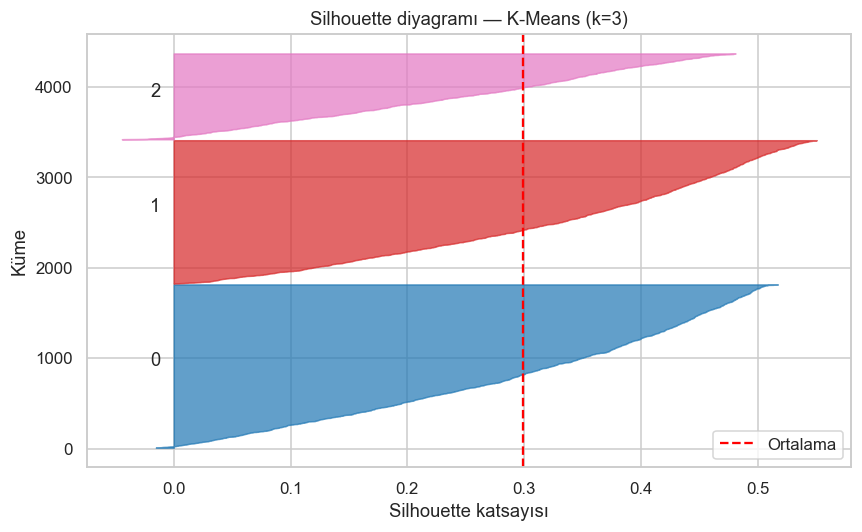

In [215]:
sample_sil = silhouette_samples(X_pca, kmeans.labels_)
y_lower = 10
fig, ax = plt.subplots(figsize=(8, 5))
for i in range(OPT_K):
    vals = np.sort(sample_sil[kmeans.labels_ == i])
    size = len(vals)
    y_upper = y_lower + size
    color = plt.cm.tab10(i / OPT_K)
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, vals,
                     facecolor=color, edgecolor=color, alpha=0.7)
    ax.text(-0.02, y_lower + 0.5*size, str(i))
    y_lower = y_upper + 10
ax.axvline(silhouette_score(X_pca, kmeans.labels_),
           color='red', ls='--', label='Ortalama')
ax.set_xlabel("Silhouette katsayısı"); ax.set_ylabel("Küme")
ax.set_title(f"Silhouette diyagramı — K-Means (k={OPT_K})")
ax.legend(); plt.tight_layout(); plt.show()

## 10. Hiyerarşik Kümeleme (Agglomerative)

Veri büyüdüğünde dendrogram okunaksızlaşır; hesap maliyeti de O(n²)'dir.
Bu yüzden temsili bir **örneklem** üzerinde dendrogram çiziyoruz, ama
nihai modeli **tüm veride** kuruyoruz.

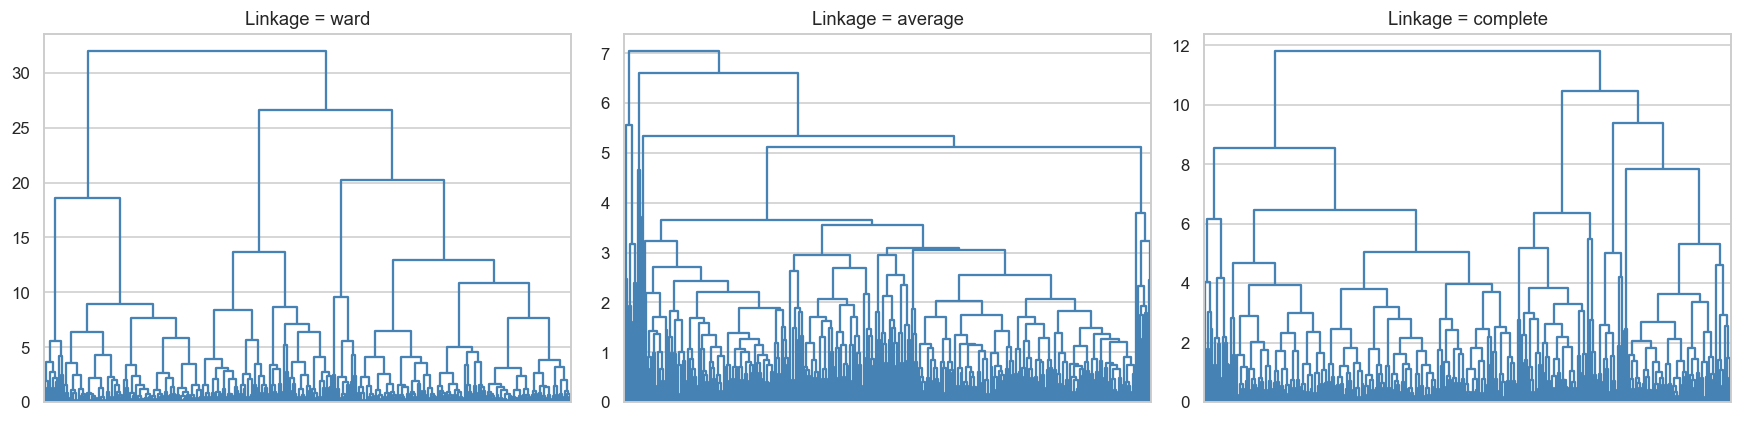

In [216]:
sample_n = min(300, len(X_pca))
sample_idx = np.random.RandomState(RND).choice(
    len(X_pca), size=sample_n, replace=False)
X_sample = X_pca.iloc[sample_idx]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, method in zip(axes, ['ward', 'average', 'complete']):
    Z = linkage(X_sample, method=method)
    dendrogram(Z, ax=ax, color_threshold=0,
               above_threshold_color='steelblue', no_labels=True)
    ax.set_title(f"Linkage = {method}")
plt.tight_layout(); plt.show()

In [217]:
# Farklı linkage'larda silhouette
for method in ['ward', 'average', 'complete']:
    hc = AgglomerativeClustering(n_clusters=OPT_K, linkage=method).fit(X_pca)
    s  = silhouette_score(X_pca, hc.labels_)
    db = davies_bouldin_score(X_pca, hc.labels_)
    print(f"{method:8s}  silhouette={s:.3f}  DBI={db:.3f}")

# Ward, Öklid uzaklığı için sıklıkla en kararlı sonucu verir
hc_final = AgglomerativeClustering(n_clusters=OPT_K, linkage='ward').fit(X_pca)
rfm['Hier_Cluster'] = hc_final.labels_

ward      silhouette=0.219  DBI=1.439
average   silhouette=0.610  DBI=0.436
complete  silhouette=0.238  DBI=1.207


## 11. DBSCAN

DBSCAN için iki kritik parametre vardır:

* `min_samples` — pratikte `2 * boyut` veya `boyut + 1`
* `eps` — *k-distance* grafiğindeki dirsek noktasından okunur

Avantajı: küme sayısını bilmek gerekmez ve gürültü (`-1`) etiketleyebilir.
Dezavantajı: değişken yoğunluklu kümelerde zayıftır.

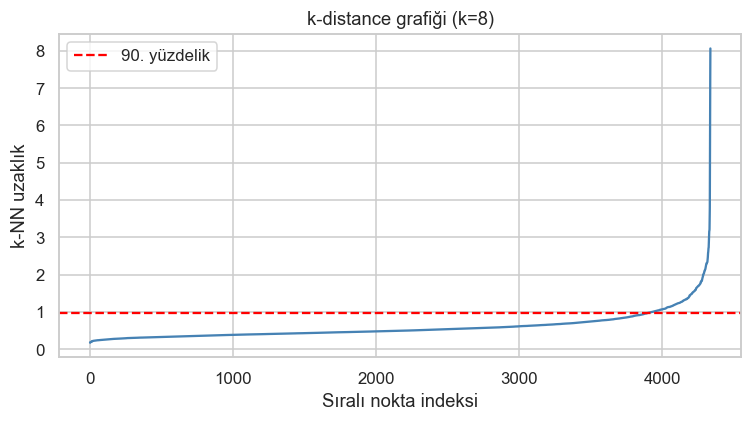

Seçilen eps = 0.978,  min_samples = 8


In [218]:
min_samples = 2 * X_pca.shape[1]
nn = NearestNeighbors(n_neighbors=min_samples).fit(X_pca)
distances, _ = nn.kneighbors(X_pca)
k_dist = np.sort(distances[:, -1])

plt.figure(figsize=(7,4))
plt.plot(k_dist, color='steelblue')
plt.axhline(np.percentile(k_dist, 90), color='red', ls='--',
            label='90. yüzdelik')
plt.title(f"k-distance grafiği (k={min_samples})")
plt.xlabel("Sıralı nokta indeksi"); plt.ylabel("k-NN uzaklık")
plt.legend(); plt.tight_layout(); plt.show()

eps = float(np.percentile(k_dist, 90))
print(f"Seçilen eps = {eps:.3f},  min_samples = {min_samples}")

In [219]:
dbscan = DBSCAN(eps=eps, min_samples=min_samples).fit(X_pca)
rfm['DBSCAN_Cluster'] = dbscan.labels_

n_noise   = int((dbscan.labels_ == -1).sum())
n_cluster = len(set(dbscan.labels_)) - (1 if -1 in dbscan.labels_ else 0)
print(f"DBSCAN  küme sayısı = {n_cluster},  gürültü noktası = {n_noise}")
print(rfm['DBSCAN_Cluster'].value_counts().sort_index())

DBSCAN  küme sayısı = 2,  gürültü noktası = 249
DBSCAN_Cluster
-1     249
 0    4081
 1       8
Name: count, dtype: int64


## 12. Algoritmaların Karşılaştırılması — Segment Geçerliliği

In [220]:
def cluster_metrics(X, labels):
    mask = labels != -1
    if mask.sum() < 2 or len(set(labels[mask])) < 2:
        return dict(silhouette=np.nan, davies_bouldin=np.nan,
                    calinski_harabasz=np.nan, n_clusters=len(set(labels))-(-1 in labels))
    return dict(
        silhouette        = silhouette_score(X[mask], labels[mask]),
        davies_bouldin    = davies_bouldin_score(X[mask], labels[mask]),
        calinski_harabasz = calinski_harabasz_score(X[mask], labels[mask]),
        n_clusters        = len(set(labels[mask])),
    )

results = pd.DataFrame({
    'KMeans'      : cluster_metrics(X_pca.values, kmeans.labels_),
    'Hierarchical': cluster_metrics(X_pca.values, hc_final.labels_),
    'DBSCAN'      : cluster_metrics(X_pca.values, dbscan.labels_),
}).T
results

,silhouette,davies_bouldin,calinski_harabasz,n_clusters
KMeans,0.298907,1.224707,1763.569880,3.0
Hierarchical,0.218830,1.438933,1282.827205,3.0
DBSCAN,0.427588,0.530518,39.489572,2.0


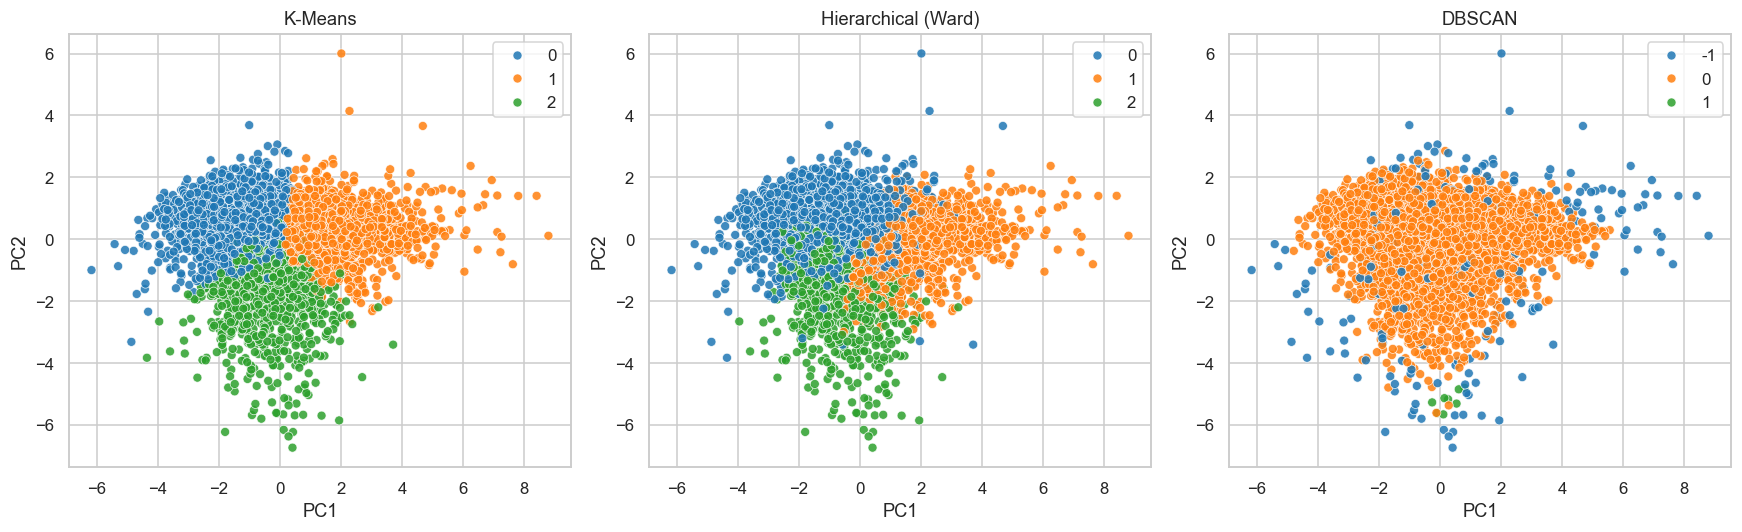

In [221]:
# Görselleştirme: 2B PCA üzerinde her algoritma
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
algo_labels = [('K-Means', kmeans.labels_),
               ('Hierarchical (Ward)', hc_final.labels_),
               ('DBSCAN', dbscan.labels_)]
for ax, (name, labels) in zip(axes, algo_labels):
    palette = sns.color_palette('tab10', n_colors=max(2, len(set(labels))))
    sns.scatterplot(x=X_pca2['PC1'], y=X_pca2['PC2'], hue=labels,
                    palette=palette, ax=ax, s=35, alpha=0.85,
                    legend='full')
    ax.set_title(name)
plt.tight_layout(); plt.show()

## 13. K-Means Segmentlerinin Yorumlanması

Her segmentin ortalama RFM ve davranışsal özelliklerine bakarak
segmentlere iş birimine konuşan isimler veriyoruz.

In [222]:
profile_cols = ['Recency','Frequency','Monetary','AvgBasketValue',
                'AvgQtyPerInvoice','UniqueProducts','Tenure','PurchaseInterval']
profile = (rfm.groupby('KMeans_Cluster')[profile_cols]
              .mean().round(2)
              .assign(Count=rfm['KMeans_Cluster'].value_counts().sort_index().values))
profile = profile.assign(
    SharePct=(profile['Count'] / profile['Count'].sum() * 100).round(1))
profile

,Recency,Frequency,Monetary,AvgBasketValue,AvgQtyPerInvoice,UniqueProducts,Tenure,PurchaseInterval,Count,SharePct
KMeans_Cluster,,,,,,,,,,
0,175.39,1.79,470.46,287.39,26.22,26.01,254.98,173.41,1805,41.6
1,32.82,8.71,4775.38,608.82,83.78,118.83,289.60,50.11,1584,36.5
2,34.63,1.58,524.79,353.24,16.29,33.31,52.41,37.03,949,21.9


In [223]:
def name_cluster(row, ranks):
    r_rank = ranks['Recency'][row.name]
    f_rank = ranks['Frequency'][row.name]
    m_rank = ranks['Monetary'][row.name]

    if r_rank == 0 and f_rank == 0 and m_rank == 0:
        return 'Champions'
    if f_rank <= 1 and m_rank <= 1:
        return 'Loyal / High Value'
    if r_rank == 0 and f_rank >= len(ranks['Recency']) - 2:
        return 'New / Promising'
    if r_rank >= len(ranks['Recency']) - 1 and f_rank <= 1:
        return 'At Risk (used to be loyal)'
    if r_rank >= len(ranks['Recency']) - 1:
        return 'Hibernating / Lost'
    return 'Need Attention'

ranks = {
    'Recency'  : profile['Recency'].rank(method='first').astype(int).sub(1),
    'Frequency': profile['Frequency'].rank(method='first', ascending=False).astype(int).sub(1),
    'Monetary' : profile['Monetary'].rank(method='first', ascending=False).astype(int).sub(1),
}
profile['SegmentName'] = profile.apply(name_cluster, axis=1, ranks=ranks)
profile[['SegmentName','Count','SharePct','Recency','Frequency','Monetary',
         'AvgBasketValue']]

,SegmentName,Count,SharePct,Recency,Frequency,Monetary,AvgBasketValue
KMeans_Cluster,,,,,,,
0,At Risk (used to be loyal),1805,41.6,175.39,1.79,470.46,287.39
1,Champions,1584,36.5,32.82,8.71,4775.38,608.82
2,Need Attention,949,21.9,34.63,1.58,524.79,353.24


In [224]:
# Segment isimlerini ana dataframe'e bağla
seg_map = profile['SegmentName'].to_dict()
rfm['Segment'] = rfm['KMeans_Cluster'].map(seg_map)
rfm[['CustomerID','Recency','Frequency','Monetary','KMeans_Cluster','Segment']].head()

,CustomerID,Recency,Frequency,Monetary,KMeans_Cluster,Segment
0,12346,326,1,77183.60,1,Champions
1,12347,2,7,4310.00,1,Champions
2,12348,75,4,1797.24,1,Champions
3,12349,19,1,1757.55,2,Need Attention
4,12350,310,1,334.40,0,At Risk (used to be loyal)


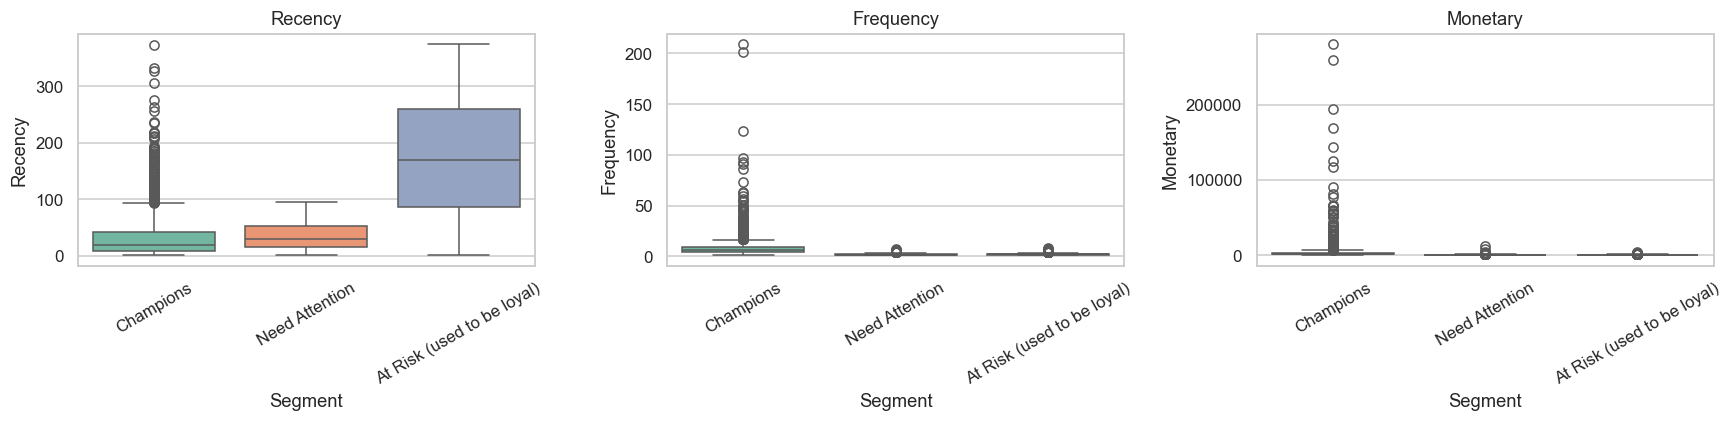

In [225]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
sns.boxplot(data=rfm, x='Segment', y='Recency',  ax=axes[0], palette='Set2')
sns.boxplot(data=rfm, x='Segment', y='Frequency',ax=axes[1], palette='Set2')
sns.boxplot(data=rfm, x='Segment', y='Monetary', ax=axes[2], palette='Set2')
for ax in axes: ax.tick_params(axis='x', rotation=30)
axes[0].set_title("Recency"); axes[1].set_title("Frequency"); axes[2].set_title("Monetary")
plt.tight_layout(); plt.show()

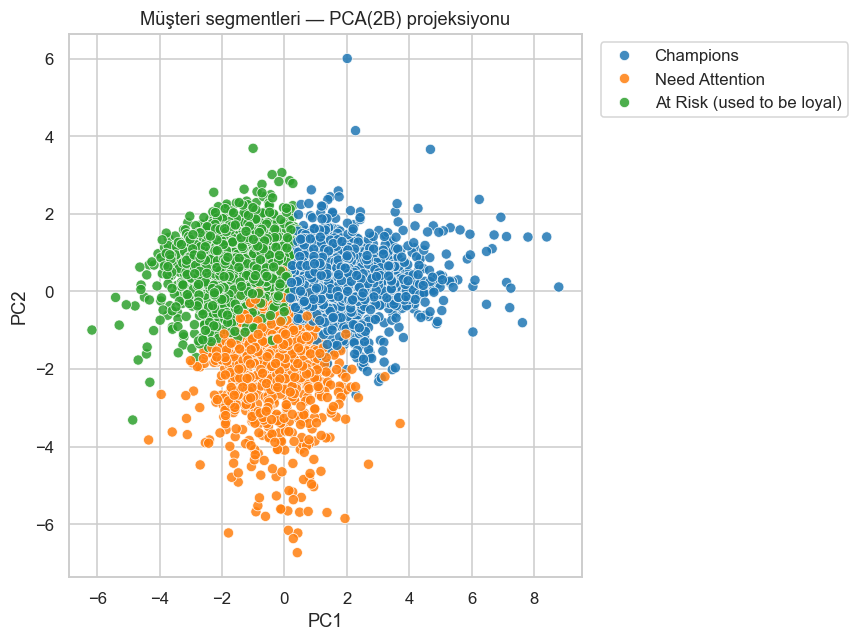

In [226]:
# Segmentlerin 2B PCA üzerinde görselleştirilmesi
plt.figure(figsize=(8,6))
sns.scatterplot(x=X_pca2['PC1'], y=X_pca2['PC2'],
                hue=rfm['Segment'], palette='tab10', s=45, alpha=0.85)
plt.title("Müşteri segmentleri — PCA(2B) projeksiyonu")
plt.legend(bbox_to_anchor=(1.02,1), loc='upper left')
plt.tight_layout(); plt.show()

## 14. Segment Geçerlilik Analizi

İki farklı testle segmentlerin sağlamlığını kontrol ediyoruz:

1. **Stabilite (Bootstrap)** — Veriden rastgele alt-örneklemler alıp
   K-Means'i tekrar çalıştırıp yeni etiketlerle eskileri arasındaki
   *adjusted Rand index* benzeri bir uyum ölçüsünü hesaplıyoruz.
2. **Cross-tab** — Rule-based RFM segmentleri ile K-Means segmentleri
   arasındaki örtüşme.

In [227]:
from sklearn.metrics import adjusted_rand_score

scores = []
for seed in range(10):
    rs = np.random.RandomState(seed)
    idx = rs.choice(len(X_pca), size=int(0.8*len(X_pca)), replace=False)
    km_b = KMeans(n_clusters=OPT_K, random_state=seed, n_init=10).fit(X_pca.iloc[idx])
    base = kmeans.predict(X_pca.iloc[idx])
    scores.append(adjusted_rand_score(base, km_b.labels_))

print("Bootstrap ARI (10 tekrar): %.3f +/- %.3f  [min %.3f, max %.3f]" % (
      np.mean(scores), np.std(scores), np.min(scores), np.max(scores)))

Bootstrap ARI (10 tekrar): 0.985 +/- 0.008  [min 0.973, max 0.997]


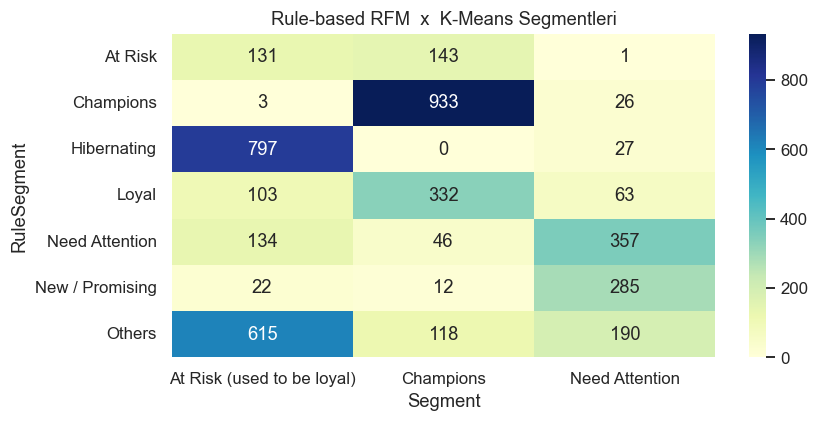

Segment,At Risk (used to be loyal),Champions,Need Attention
RuleSegment,,,
At Risk,131,143,1
Champions,3,933,26
Hibernating,797,0,27
Loyal,103,332,63
Need Attention,134,46,357
New / Promising,22,12,285
Others,615,118,190


In [228]:
ct = pd.crosstab(rfm['RuleSegment'], rfm['Segment'])
plt.figure(figsize=(8,4))
sns.heatmap(ct, annot=True, fmt='d', cmap='YlGnBu')
plt.title("Rule-based RFM  x  K-Means Segmentleri")
plt.tight_layout(); plt.show()
ct

## 15. Sonuçların Dışa Aktarılması

In [229]:
os.makedirs('outputs', exist_ok=True)
rfm.to_csv('outputs/customer_segments.csv', index=False)
profile.to_csv('outputs/segment_profiles.csv')
print("Yazıldı: outputs/customer_segments.csv  ve  outputs/segment_profiles.csv")
profile

Yazıldı: outputs/customer_segments.csv  ve  outputs/segment_profiles.csv


,Recency,Frequency,Monetary,AvgBasketValue,AvgQtyPerInvoice,UniqueProducts,Tenure,PurchaseInterval,Count,SharePct,SegmentName
KMeans_Cluster,,,,,,,,,,,
0,175.39,1.79,470.46,287.39,26.22,26.01,254.98,173.41,1805,41.6,At Risk (used to be loyal)
1,32.82,8.71,4775.38,608.82,83.78,118.83,289.60,50.11,1584,36.5,Champions
2,34.63,1.58,524.79,353.24,16.29,33.31,52.41,37.03,949,21.9,Need Attention


## 16. Sonuç ve Öğrenilenler

**Yöntem akışı:** İşlem verisinden RFM + davranışsal özellikler türetildi,
log+StandardScaler ile çarpıklık ve ölçek farkı düzeltildi, PCA ile boyut
indirgendi (curse of dimensionality), ardından K-Means / Hierarchical /
DBSCAN birlikte değerlendirildi.

**Optimal `k` seçimi:** Elbow + Silhouette + Davies-Bouldin +
Calinski-Harabasz birlikte kullanıldı. Tek bir metrik yerine *konsensüs*
yaklaşımı tercih edildi.

**Algoritma karşılaştırması:** K-Means küresel kümelerde net çalıştı;
Ward linkage ile hiyerarşik kümeleme benzer ama daha yumuşak sınırlar
verdi; DBSCAN parametre seçimine duyarlıydı, gürültü noktalarını
ayıklayabildi.

**Segment yorumu:** Champions, Loyal/High Value, New/Promising,
Need Attention, At Risk ve Hibernating gibi pazarlama dilinde anlamlı
segmentler ortaya çıktı. Cross-tab analizi rule-based RFM ile büyük
oranda örtüştüğünü gösterdi -> segmentler yorumlanabilir.

**Geçerlilik:** Bootstrap ARI yüksek (yakınsayan etiketler) -> segmentler
kararlı.

**Pazarlama önerileri (özet):**
* *Champions*: VIP programı, erken erişim, sadakat ödülleri
* *Loyal*: cross-sell ve upsell kampanyaları
* *New*: onboarding e-postaları, ikinci-sipariş indirimi
* *Need Attention*: kişiselleştirilmiş hatırlatmalar
* *At Risk*: win-back kampanyaları
* *Hibernating*: maliyetli müşteri-edinim yerine düşük-maliyetli reaktivasyon